In [760]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression,RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import confusion_matrix,mean_squared_error,r2_score,mean_absolute_error,accuracy_score, classification_report,accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")

# 1. Data Loading

In [761]:
df= pd.read_csv('diabetes.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 2. Data Preprocessing

In [762]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


``` 
No categorical values so no need to encoding 
```

In [763]:
# if categorical values exist

# cat_features=['Glucose', 'BMI', 'DiabetesPedigreeFunction']
# encoded_df=pd.get_dummies(
#     df,
#     columns=cat_features,
#     dtype=int
# )

In [764]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [765]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

```
No missing value. If exist then i will replace it with mean value, becase it is numarical value
```

In [766]:
# if null valu exist
# glucose_mean=df['Glucose'].mean()
# df['Glucose']=df['Glucose'].fillna(glucose_mean)

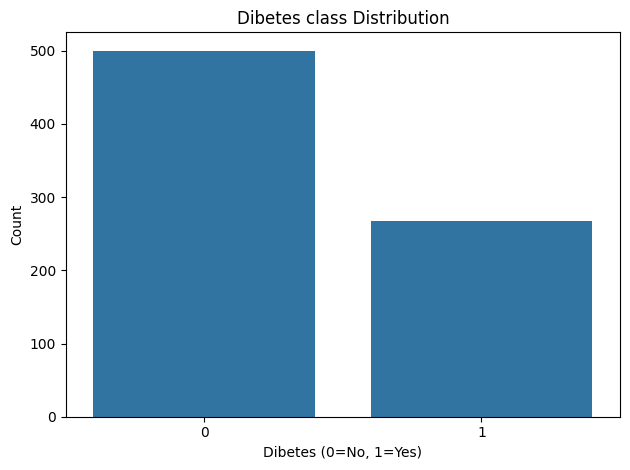

In [767]:
plt.Figure(figsize=(10, 6))
sns.countplot(x=df['Outcome'])
plt.title("Dibetes class Distribution")
plt.xlabel("Dibetes (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Box plot to understand outliers

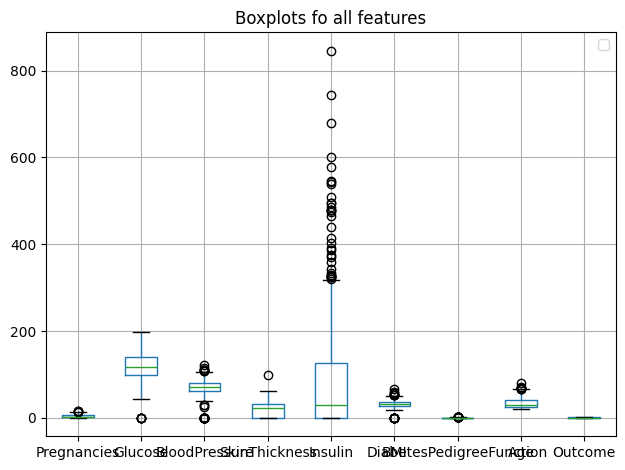

In [768]:
plt.Figure(figsize=(10, 6))
df.boxplot()
plt.title('Boxplots fo all features')
plt.legend()
plt.tight_layout()
plt.show()

In [769]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

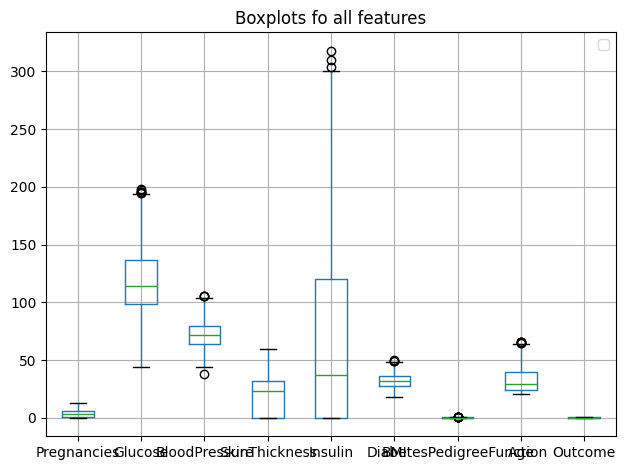

In [770]:
plt.Figure(figsize=(10, 6))
df.boxplot()
plt.title('Boxplots fo all features')
plt.legend()
plt.tight_layout()
plt.show()

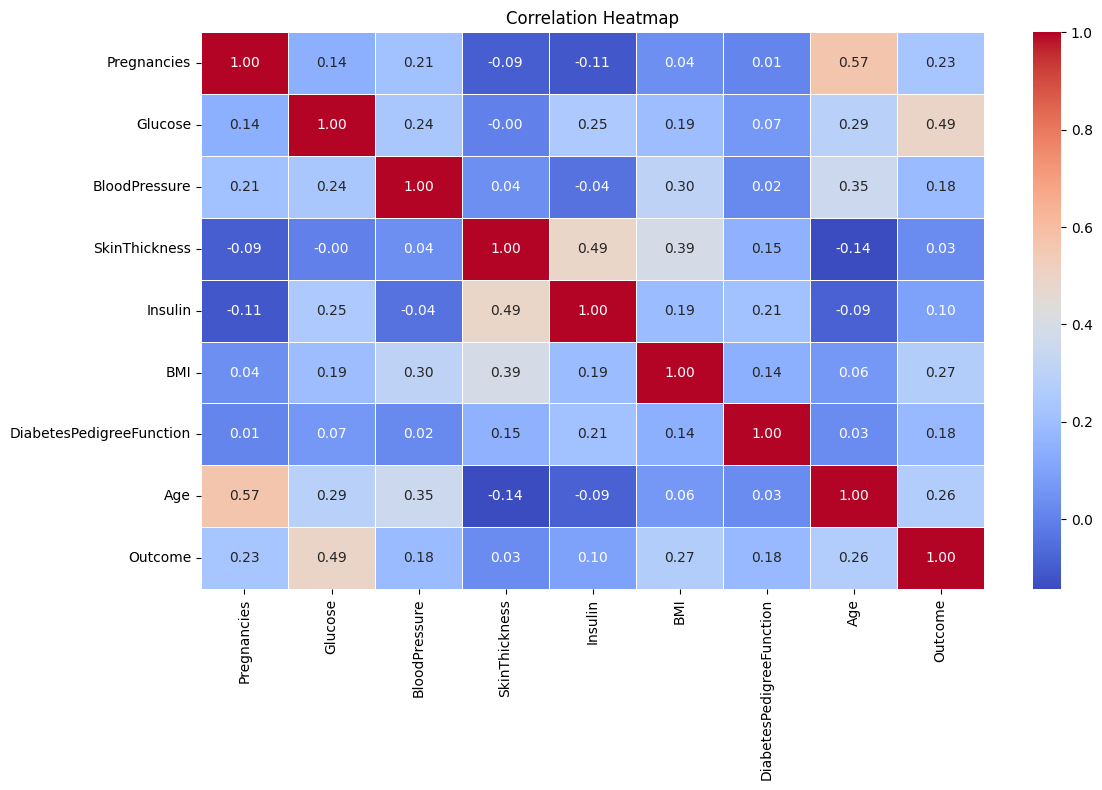

In [771]:
corr_matrix = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [772]:
X= df.drop('Outcome',axis=1)
y=df['Outcome']

In [773]:
print(X.shape)
print(y.shape)

(639, 8)
(639,)


In [774]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [775]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model build

In [776]:
clf_lr = LogisticRegression(max_iter=1000)
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf_dt = DecisionTreeClassifier(random_state=42)
clf_svm = SVC(random_state=42)
clf_nb = BernoulliNB()
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_ada = AdaBoostClassifier(
    n_estimators=100, estimator=DecisionTreeClassifier(max_depth=1, random_state=42),random_state=42
)
clf_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [777]:
model_to_train = {
    'Logistic Regression' : clf_lr,
    'Random Forest' : clf_rf,
    'Gradient Boosting': clf_gb,
    'Decision Tree': clf_dt,
    'SVM': clf_svm,
    'NB': clf_nb,
    'AdaBoost': clf_ada,
    'XGBoost': clf_xgb,
    'KNN': clf_knn
}

# 3. Pipeline Creation and 5. traning

In [778]:
result = []

for name, model in model_to_train.items():
    pip = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    pip.fit(X_train, y_train)
    
    y_pred = pip.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    result.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(result).sort_values("F1 Score", ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
2    Gradient Boosting  0.851562   0.847574  0.851562  0.847987
1        Random Forest  0.820312   0.814610  0.820312  0.815985
0  Logistic Regression  0.828125   0.826812  0.828125  0.813458
7              XGBoost  0.804688   0.814489  0.804688  0.808301
8                  KNN  0.804688   0.795689  0.804688  0.795291
6             AdaBoost  0.804688   0.795643  0.804688  0.792586
4                  SVM  0.796875   0.789931  0.796875  0.775982
5                   NB  0.742188   0.725557  0.742188  0.729783
3        Decision Tree  0.726562   0.724280  0.726562  0.725376


# 4. Primary Model Selection 

```
I chose tree-based models for classification because they capture complex, non-linear patterns and can handle both numerical and categorical features. They also offer good accuracy and interpretability through decision rules or feature importance, making them well-suited for this dataset.
```

# 6. Cross-Validation

In [779]:
results = []

for name, model in model_to_train.items():
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),   # Scaling applied
        ('model', model)
    ])
    
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    
    print(f"\n{name}")
    print("Scores:", scores)
    print("Mean Accuracy:", scores.mean())
    print("Std Dev:", scores.std())
    
    results.append((name, scores.mean(), scores.std()))


Logistic Regression
Scores: [0.7890625  0.7734375  0.765625   0.796875   0.80314961]
Mean Accuracy: 0.7856299212598425
Std Dev: 0.01409982813617535

Random Forest
Scores: [0.7890625  0.7734375  0.734375   0.8046875  0.77952756]
Mean Accuracy: 0.7762180118110236
Std Dev: 0.02343081142806888

Gradient Boosting
Scores: [0.8125     0.765625   0.765625   0.7578125  0.80314961]
Mean Accuracy: 0.7809424212598425
Std Dev: 0.02233060630123387

Decision Tree
Scores: [0.7265625  0.59375    0.6953125  0.703125   0.69291339]
Mean Accuracy: 0.6823326771653544
Std Dev: 0.04586047493696994

SVM
Scores: [0.7890625  0.7578125  0.765625   0.8046875  0.78740157]
Mean Accuracy: 0.78091781496063
Std Dev: 0.016977035853215597

NB
Scores: [0.734375   0.71875    0.7421875  0.75       0.73228346]
Mean Accuracy: 0.7355191929133859
Std Dev: 0.0104608320854756

AdaBoost
Scores: [0.78125    0.734375   0.75       0.8046875  0.79527559]
Mean Accuracy: 0.7731176181102362
Std Dev: 0.026792474859760874

XGBoost
Scores:

In [780]:
results_df = pd.DataFrame(results, columns=["Model", "Mean Accuracy", "Std Dev"])
results_df = results_df.sort_values(by="Mean Accuracy", ascending=False)

print(results_df)

                 Model  Mean Accuracy   Std Dev
0  Logistic Regression       0.785630  0.014100
2    Gradient Boosting       0.780942  0.022331
4                  SVM       0.780918  0.016977
1        Random Forest       0.776218  0.023431
6             AdaBoost       0.773118  0.026792
7              XGBoost       0.759018  0.014831
8                  KNN       0.757505  0.032714
5                   NB       0.735519  0.010461
3        Decision Tree       0.682333  0.045860


# 7. Hyperparameter Tuning (Grid search cv)

In [781]:
param_grids = {
    "Logistic Regression": {
        'model__C': [0.1, 1, 10]
    },
    
    "Random Forest": {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 5, 10]
    },
    
    "Gradient Boosting": {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1]
    },
    
    "Decision Tree": {
        'model__max_depth': [None, 5, 10],
        'model__min_samples_split': [2, 5]
    },
    
    "SVM": {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf']
    },
    
    "Naive Bayes": {
    'model__var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    
    "KNN": {
        'model__n_neighbors': [3, 5, 7],
        'model__weights': ['uniform', 'distance']
    },
    
    "AdaBoost": {
        'model__n_estimators': [50, 100],
        'model__learning_rate': [0.5, 1.0]
    },
    
    "XGBoost": {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.01, 0.1]
    }
}

In [782]:
best_models = []

for name, model in model_to_train.items():
    
    if name not in param_grids:
        continue
    
    print(f"\n Tuning {name}...")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_models.append({
        "Model": name,
        "Best Score": grid.best_score_,
        "Best Params": grid.best_params_
    })
    
    print("Best Score:", grid.best_score_)
    print("Best Params:", grid.best_params_)


 Tuning Logistic Regression...
Best Score: 0.7787930706263089
Best Params: {'model__C': 10}

 Tuning Random Forest...
Best Score: 0.7710641538168665
Best Params: {'model__max_depth': 5, 'model__n_estimators': 100}

 Tuning Gradient Boosting...
Best Score: 0.7533980582524272
Best Params: {'model__learning_rate': 0.01, 'model__n_estimators': 100}

 Tuning Decision Tree...
Best Score: 0.7024557395773844
Best Params: {'model__max_depth': 5, 'model__min_samples_split': 5}

 Tuning SVM...
Best Score: 0.7748905387397678
Best Params: {'model__C': 0.1, 'model__kernel': 'linear'}

 Tuning AdaBoost...
Best Score: 0.7553588425661527
Best Params: {'model__learning_rate': 0.5, 'model__n_estimators': 100}

 Tuning XGBoost...
Best Score: 0.7553588425661527
Best Params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}

 Tuning KNN...
Best Score: 0.737845040928993
Best Params: {'model__n_neighbors': 5, 'model__weights': 'uniform'}


In [783]:
best_estimators = {}

for name, model in model_to_train.items():
    if name not in param_grids:
        continue
        
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    grid = GridSearchCV(pipeline, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_estimators[name] = grid.best_estimator_

# Ensemble voting and staking

In [784]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', best_estimators['Logistic Regression']),
        ('svm', best_estimators['SVM']),
        ('gb', best_estimators['Gradient Boosting'])
    ],
    voting='hard'
)

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', best_estimators['Logistic Regression']),
        ('svm', best_estimators['SVM']),
        ('gb', best_estimators['Gradient Boosting'])
    ],
    final_estimator=RidgeClassifier()
)

In [785]:
model_to_train = {
    "Logistic Regression": clf_lr,
    "Random Forest": clf_rf,
    "Gradient Boosting": clf_gb,
    "Decision Tree": clf_dt,
    "SVM": clf_svm,
    "Naive Bayes": clf_nb,
    "AdaBoost": clf_ada,
    "XGBoost": clf_xgb,
    "KNN": clf_knn,
    'Voting Ensemble': voting_clf,
    'Staking Ensemble': stacking_clf
}

In [786]:
result = []

for name, model in model_to_train.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    result.append({
        "Model": name,
        "Accuracy": acc
    })

results_df = pd.DataFrame(result).sort_values("Accuracy", ascending=False)

print(results_df)

                  Model  Accuracy
2     Gradient Boosting  0.851562
0   Logistic Regression  0.812500
9       Voting Ensemble  0.812500
1         Random Forest  0.804688
4                   SVM  0.804688
7               XGBoost  0.804688
6              AdaBoost  0.804688
10     Staking Ensemble  0.804688
8                   KNN  0.781250
3         Decision Tree  0.726562
5           Naive Bayes  0.718750


# 8. Best Model Selection

In [787]:
best_model = model_to_train[results_df.iloc[0]['Model']]

# 9. Model Performance Evaluation

In [788]:
print("\nBest Model:", results_df.iloc[0]['Model'])
print(classification_report(y_test, best_model.predict(X_test)))
print("==========Confusion Matrix==========\n",confusion_matrix(y_test, best_model.predict(X_test)))


Best Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        92
           1       0.77      0.67      0.72        36

    accuracy                           0.85       128
   macro avg       0.83      0.80      0.81       128
weighted avg       0.85      0.85      0.85       128

==========Confusion Matrix==========
 [[85  7]
 [12 24]]


In [789]:
import pickle

filename='model.pkl'

with open(filename, 'wb') as file:
    pickle.dump(best_model, file)

In [790]:
with open('model.pkl', 'rb') as file:
    ok=pickle.load(file)